In [ ]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
x,y = make_regression(n_samples=100, n_features=1, noise=20,n_targets=1,random_state=19)

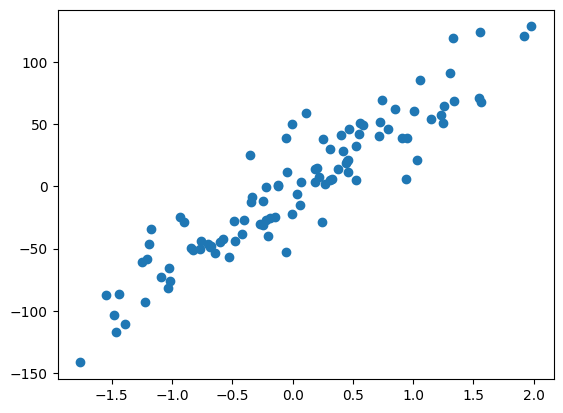

In [ ]:
plt.scatter(x,y
            )

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)

LinearRegression()

In [ ]:
lr.coef_

array([60.52658394])

In [ ]:
lr.intercept_

np.float64(-2.0441061386071055)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
rr = Ridge(alpha=10)
rr.fit(x,y)

Ridge(alpha=10)

In [ ]:
print(rr.coef_)
print(rr.intercept_)

[53.19745195]
-1.8658355149866952


In [ ]:
#increases alpha,, coeff must reduce
rr1 = Ridge(alpha=100)
rr1.fit(x,y)

Ridge(alpha=100)

In [ ]:
print(rr1.coef_)
print(rr1.intercept_)

[25.45569852]
-1.1910571517457305


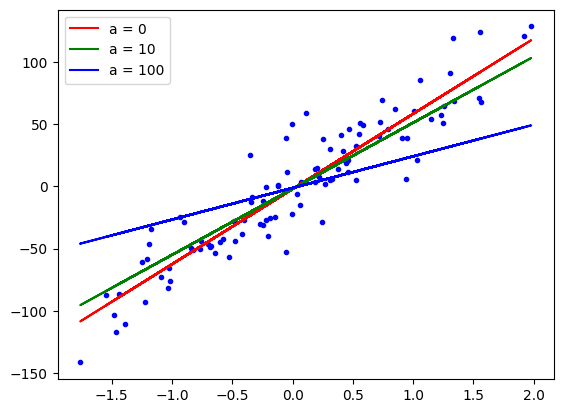

In [ ]:
plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),'r',label = 'a = 0')
plt.plot(x,rr.predict(x),'g',label = 'a = 10')
plt.plot(x,rr1.predict(x),'b',label = 'a = 100')
plt.legend()

In [ ]:
class MRidge:

  def __init__(self,alpha= 0.1):
    self.alpha = alpha
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
    num = 0
    dem = 0

    for i in range(X_train.shape[0]):
      num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
      dem = dem + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())

    self.m = num/(dem+ self.alpha)
    self.b = y_train.mean() - self.m*X_train.mean()
    print(self.m,self.b)

    # self.m = num/(dem + self.alpha)

    def predict(self,X_test):
      return self.m*X_test + self.b

In [ ]:
MR = MRidge(alpha=100)
MR.fit(x,y)

[25.45569852] [-1.19105715]


## **Coding Ridge Regression from Scratch:**

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [ ]:
x,y = load_diabetes(return_X_y=True)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
reg = Ridge(alpha=0.1,solver='cholesky')
reg.fit(X_train,y_train)

Ridge(alpha=0.1, solver='cholesky')

In [ ]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.45199494197195456

In [ ]:
print(reg.coef_)
print(reg.intercept_)

[   6.64373321 -172.23747375  485.52958514  314.67584612  -72.94020918
  -80.58868817 -174.46352722   83.61470987  484.36531622   73.58509056]
151.92546856900984


In [12]:
class MRidge:

  def __init__(self,alpha=0.1):
    self.alpha = alpha
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train,y_train):
    X_train = np.insert(X_train,0,1,axis=1) #Adds 1 as first col to x_train
    I = np.identity(X_train.shape[1]) #Creating Identity matrix for calculation
    # I[0][0] = 0 #Setting first element of identity matrix to 0, in sklearn
    result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha*I).dot(X_train.T).dot(y_train) #calculating loss function for ridge
    self.intercept_ = result[0]
    self.coef_ = result[1:]
    # print(self.intercept_,self.coef_)


  def predict(self,X_test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred


In [13]:
reg = MRidge(alpha=0.1)
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print('R2 score: ',r2_score(y_test,y_pred))
print(reg.intercept_,reg.coef_)

R2 score:  0.45199494197195456
151.9254685690099 [   6.64373321 -172.23747375  485.52958514  314.67584612  -72.94020918
  -80.58868817 -174.46352722   83.61470987  484.36531622   73.58509056]
